# Bitbrain Open Access Sleep Dataset + Sleep Classification

## Imports

In [1]:
from __future__ import annotations

import os
import json
from pathlib import Path
from typing import List, Tuple
from collections import Counter

from joblib import Parallel, delayed
import mne
from numba import njit
import numpy as np
import pandas as pd
from scipy.signal import welch, coherence, medfilt, butter, filtfilt, find_peaks, hilbert
from scipy.stats import skew, linregress, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("[WARN] imblearn not installed; SMOTE disabled. Run: pip install imbalanced-learn")

# =============================
# Config
# =============================
EPOCH_SEC = 30
EEG_CHANNELS = 2
IMU_CHANNELS = 3
EEG_FS = 256
IMU_FS = 30
STAGE_LABELS = ["Wake", "N1", "N2", "N3", "REM"]

## Functions

In [2]:
# =============================
# Feature extraction
# =============================

@njit
def lempel_ziv_complexity(sequence: np.ndarray) -> float:
    n = len(sequence)
    m = np.median(sequence)
    s = sequence > m
    c = 1
    l = 1
    i = 0
    k = 1
    while k + l <= n:
        if np.array_equal(s[i:i + l], s[k:k + l]):
            l += 1
        else:
            c += 1
            k += l
            l = 1
            i = 0
    return c / (n / np.log2(n) + 1e-12)

def hjorth_params(x: np.ndarray) -> tuple[float, float, float]:
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0 = float(np.var(x) + 1e-12)
    var1 = float(np.var(dx) + 1e-12)
    var2 = float(np.var(ddx) + 1e-12)
    activity = var0
    mobility = float(np.sqrt(var1 / var0))
    complexity = float(np.sqrt(var2 / var1) / (mobility + 1e-12))
    return activity, mobility, complexity

def spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))

def spectral_edge_frequency(f: np.ndarray, psd: np.ndarray, edge: float = 0.95) -> float:
    cumulative = np.cumsum(psd)
    if len(cumulative) == 0 or cumulative[-1] <= 0:
        return 0.0
    threshold = edge * cumulative[-1]
    idx = int(np.searchsorted(cumulative, threshold, side="left"))
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def spindle_density(x: np.ndarray, fs: float = EEG_FS) -> float:
    b, a = butter(4, [11.0, 16.0], btype='band', fs=fs)
    env = np.abs(hilbert(filtfilt(b, a, x)))
    thresh = np.mean(env) + 1.5 * np.std(env)
    peaks, _ = find_peaks(env, height=thresh, distance=int(fs * 0.5))
    return len(peaks) / (len(x) / fs)

def eeg_features(eeg: np.ndarray, fs: float = EEG_FS) -> np.ndarray:
    feats = []
    bands = {
        "delta": (0.5, 4.0),
        "theta": (4.0, 8.0),
        "alpha": (8.0, 12.0),
        "sigma": (12.0, 16.0),
        "beta":  (16.0, 30.0),
    }
    extra_bands = {
        "so":           (0.5, 2.0),
        "narrow_theta": (4.0, 7.0),
        "spindle":      (12.0, 15.0),
    }

    b_d, a_d = butter(4, [0.5, 4.0], btype='band', fs=fs)
    ch_psd_list = []  # store per-channel PSD for asymmetry computation

    for ch in range(eeg.shape[0]):
        x = eeg[ch].astype(float)
        f, psd = welch(x, fs=fs, nperseg=int(fs * 4))
        ch_psd_list.append((f.copy(), psd.copy()))
        total = np.sum(psd) + 1e-12

        ch_feats = []

        # Standard bands: log power + relative power
        band_powers = {}
        for name, (lo, hi) in bands.items():
            mask = (f >= lo) & (f < hi)
            val = float(np.sum(psd[mask])) if np.any(mask) else 0.0
            band_powers[name] = val
            ch_feats.append(10.0 * np.log10(val + 1e-12))
            ch_feats.append(val / total)

        # Extra sub-bands: log power + relative power
        for name, (lo, hi) in extra_bands.items():
            mask = (f >= lo) & (f < hi)
            val = float(np.sum(psd[mask])) if np.any(mask) else 0.0
            ch_feats.append(10.0 * np.log10(val + 1e-12))
            ch_feats.append(val / total)

        # Discriminative power ratios
        so_mask = (f >= 0.5) & (f < 2.0)
        so_p    = float(np.sum(psd[so_mask])) if np.any(so_mask) else 0.0
        beta_p  = band_powers["beta"]  + 1e-12
        delta_p = band_powers["delta"] + 1e-12
        theta_p = band_powers["theta"] + 1e-12
        alpha_p = band_powers["alpha"] + 1e-12
        sigma_p = band_powers["sigma"] + 1e-12
        ch_feats.append(so_p    / beta_p)   # SO/beta   — high in N3
        ch_feats.append(beta_p  / delta_p)  # beta/delta — high in Wake
        ch_feats.append(theta_p / alpha_p)  # theta/alpha — high in N1
        ch_feats.append(sigma_p / theta_p)  # sigma/theta — high in N2

        # Frontal theta fraction — theta/(theta+alpha): high in N1 (alpha fading, theta rising)
        ch_feats.append(theta_p / (theta_p + alpha_p + 1e-12))

        # Spectral slope (1/f)
        mask_slope = (f >= 0.5) & (f <= 30.0)
        log_f   = np.log10(f[mask_slope]   + 1e-12)
        log_psd = np.log10(psd[mask_slope] + 1e-12)
        slope, _, _, _, _ = linregress(log_f, log_psd)
        ch_feats.append(slope)

        # Hjorth + spectral entropy + Lempel-Ziv
        activity, mobility, complexity = hjorth_params(x)
        ch_feats.extend([activity, mobility, complexity, spectral_entropy(psd)])
        ch_feats.append(lempel_ziv_complexity(x))

        # Time-domain Wake discriminators
        ch_feats.append(float(np.mean(np.abs(np.diff(x)))))           # line length
        ch_feats.append(float(kurtosis(x)))                            # signal kurtosis
        ch_feats.append(float(skew(x)))                                # skewness
        ch_feats.append(float(np.sqrt(np.mean(x ** 2))))               # RMS
        ch_feats.append(float(np.max(x) - np.min(x)))                  # peak-to-peak
        ch_feats.append(float(np.sum(np.diff(np.sign(x)) != 0) / len(x)))  # ZCR

        # Spectral peak + edge
        ch_feats.append(float(f[np.argmax(psd)]))
        ch_feats.append(spectral_edge_frequency(f, psd))

        # Delta kurtosis — K-complex proxy for N2
        delta_sig = filtfilt(b_d, a_d, x)
        ch_feats.append(float(kurtosis(delta_sig)))

        # Spindle density — N2 vs N1 discriminator
        ch_feats.append(spindle_density(x, fs=fs))

        # Alpha peak frequency — Wake (~10 Hz) vs N1 (drifts toward theta ~8 Hz)
        alpha_mask_p = (f >= 8.0) & (f < 12.0)
        ch_feats.append(float(f[alpha_mask_p][np.argmax(psd[alpha_mask_p])]) if np.any(alpha_mask_p) else 10.0)

        # Slow-wave amplitude: peak and p90 — N3 discriminator
        so_sig = filtfilt(b_d, a_d, x)
        ch_feats.append(float(np.max(np.abs(so_sig))))
        ch_feats.append(float(np.percentile(np.abs(so_sig), 90)))

        # Additional cross-band ratios
        ch_feats.append(alpha_p / (beta_p + 1e-12))              # alpha/beta: high in relaxed Wake
        ch_feats.append(delta_p / (sigma_p + 1e-12))              # delta/sigma: high in N3 vs N2
        ch_feats.append(sigma_p / (theta_p + delta_p + 1e-12))    # spindle vs slow activity: N2 vs N3

        feats.extend(ch_feats)

    # Inter-channel coherence (delta + theta) — global sync marker for N3/N1
    if eeg.shape[0] >= 2:
        f_coh, coh = coherence(eeg[0], eeg[1], fs=fs, nperseg=int(fs * 4))
        delta_coh = float(np.mean(coh[(f_coh >= 0.5) & (f_coh <= 4.0)]))
        theta_coh = float(np.mean(coh[(f_coh >= 4.0) & (f_coh <= 8.0)]))
        feats.extend([delta_coh, theta_coh])

        # Hemispheric asymmetry (AF7 vs AF8) in alpha, delta, sigma — lateralization marker
        for lo, hi in [(8.0, 12.0), (0.5, 4.0), (12.0, 16.0)]:
            f0, psd0 = ch_psd_list[0]
            f1, psd1 = ch_psd_list[1]
            m0 = (f0 >= lo) & (f0 < hi)
            m1 = (f1 >= lo) & (f1 < hi)
            p0 = float(np.sum(psd0[m0])) + 1e-12
            p1 = float(np.sum(psd1[m1])) + 1e-12
            feats.append((p0 - p1) / (p0 + p1))
    else:
        feats.extend([0.0, 0.0, 0.0, 0.0, 0.0])  # coherence + asymmetry placeholders

    return np.asarray(feats, dtype=np.float32)

# =============================
# Subject-Wise Scaling Logic
# =============================

def scale_subject_features(X: np.ndarray) -> np.ndarray:
    if len(X) == 0:
        return X
    return RobustScaler().fit_transform(X)

def imu_features(accel: np.ndarray, fs: float = IMU_FS) -> np.ndarray:
    # Remove gravity
    accel_dyn = accel - np.mean(accel, axis=0)
    mag = np.sqrt(np.sum(accel_dyn ** 2, axis=1))

    # Movement event count
    sigma = float(np.std(mag)) + 1e-9
    thresh = float(np.mean(mag)) + 2.0 * sigma
    n_events = float(np.sum(mag > thresh))
    peak_amp = float(np.max(mag))
    p95 = float(np.percentile(mag, 95))

    # Jerk (first derivative of magnitude)
    jerk = np.diff(mag)
    mean_jerk = float(np.mean(np.abs(jerk))) if len(jerk) else 0.0
    std_jerk  = float(np.std(jerk))           if len(jerk) else 0.0
    peak_jerk = float(np.max(np.abs(jerk)))   if len(jerk) else 0.0

    # Respiration proxy — regularity differentiates Wake/REM from NREM
    nyq = fs / 2.0
    resp_power = 0.0
    resp_irregularity = 0.0
    min_len = int(fs * 10)
    if len(mag) >= min_len and nyq > 0.4:
        b, a = butter(2, [0.15 / nyq, 0.4 / nyq], btype="band")
        resp = filtfilt(b, a, mag)
        resp_power = float(np.var(resp))
        zc_idx = np.where(np.diff(np.sign(resp)))[0]
        if len(zc_idx) > 3:
            ibi = np.diff(zc_idx).astype(float)
            resp_irregularity = float(np.std(ibi) / (np.mean(ibi) + 1e-9))

    # Spectral features on dynamic magnitude
    f, psd = welch(mag, fs=fs, nperseg=min(256, len(mag)))
    resp_band_pwr = float(np.sum(psd[(f >= 0.15) & (f <= 0.4)]))
    move_band_pwr = float(np.sum(psd[f > 0.5]))
    dom_freq      = float(f[np.argmax(psd)]) if len(f) else 0.0

    # Per-axis RMS and std (directional movement)
    per_axis = []
    for ax in range(min(accel_dyn.shape[1], 3)):
        x = accel_dyn[:, ax]
        per_axis.extend([float(np.std(x)), float(np.sqrt(np.mean(x ** 2)))])

    any_movement = float(n_events > 0)

    return np.array([
        any_movement,
        float(np.mean(mag)), float(np.std(mag)), float(np.var(mag)),
        peak_amp, p95,
        n_events,
        mean_jerk, std_jerk, peak_jerk,
        resp_band_pwr, move_band_pwr, dom_freq,
        resp_power, resp_irregularity,
        *per_axis,
    ], dtype=np.float32)

# =============================
# Helpers
# =============================

def normalize_stage(label):
    if pd.isna(label):
        return None
    text = str(label).strip().lower()
    mapping = {
        "0": "Wake", "wake": "Wake", "w": "Wake",
        "1": "N1",   "n1": "N1",    "nrem1": "N1",  "sleep stage n1": "N1",
        "2": "N2",   "n2": "N2",    "nrem2": "N2",  "sleep stage n2": "N2",
        "3": "N3",   "n3": "N3",    "nrem3": "N3",  "sleep stage n3": "N3",
        "4": "REM",  "rem": "REM",  "r": "REM",     "sleep stage r": "REM",
        "-2": None, "8": None, "nan": None, "none": None, "unknown": None,
    }
    return mapping.get(text, None)


def subject_is_multimodal(sub_dir: Path) -> bool:
    sub = sub_dir.name
    eeg_dir = sub_dir / "eeg"
    ch = eeg_dir / f"{sub}_task-Sleep_acq-headband_channels.tsv"
    if not ch.exists():
        return False
    df = pd.read_csv(ch, sep="\t")
    names = [str(x).strip().lower() for x in df["name"]]
    has_eeg = ("hb_1" in names and "hb_2" in names)
    has_imu = sum(n.startswith("hb_imu") for n in names) >= 3
    return has_eeg and has_imu


def pick_eeg_channels(raw):
    return [ch for ch in raw.ch_names if ch.lower() in ("hb_1", "hb_2")]


def pick_imu_channels(raw):
    imu = [ch for ch in raw.ch_names if "hb_imu" in ch.lower()]
    imu = sorted(imu, key=lambda s: int("".join(filter(str.isdigit, s)) or 0))
    return imu[:IMU_CHANNELS]

# =============================
# Data loader
# =============================

def add_temporal_context(X: np.ndarray, window: int = 3) -> np.ndarray:
    """Concatenate [t-window … t … t+window] features plus epoch-to-epoch
    gradient features (current - prev, next - current) for each epoch.
    Gradients make the alpha-attenuation transition of N1 explicit to the RF."""
    if len(X) == 0:
        return X
    n = len(X)
    out = []
    for i in range(n):
        frames = [X[max(0, min(n - 1, i + d))] for d in range(-window, window + 1)]
        prev_frame = frames[window - 1]
        curr_frame = frames[window]
        next_frame = frames[window + 1]
        grad_prev = (curr_frame - prev_frame).astype(np.float32)
        grad_next = (next_frame - curr_frame).astype(np.float32)
        out.append(np.concatenate([*frames, grad_prev, grad_next]).astype(np.float32))
    return np.vstack(out)


def _process_subject(sub_dir: Path) -> dict | None:
    """Load, filter, and extract features for one subject. Called in parallel."""
    sub = sub_dir.name
    eeg_dir = sub_dir / "eeg"
    edf    = eeg_dir / f"{sub}_task-Sleep_acq-headband_eeg.edf"
    events = eeg_dir / f"{sub}_task-Sleep_acq-psg_events.tsv"

    try:
        raw = mne.io.read_raw_edf(edf, preload=True, verbose="ERROR")
        raw.filter(0.5, 30.0, verbose="ERROR")
    except Exception as e:
        print(f"[SKIP] {sub}: EDF read/filter failed: {type(e).__name__}: {e}")
        return None

    eeg_ch = pick_eeg_channels(raw)
    imu_ch = pick_imu_channels(raw)

    if len(eeg_ch) < 2 or len(imu_ch) < 3:
        print(f"[SKIP] {sub}: eeg_ch={eeg_ch}, imu_ch={imu_ch}")
        return None

    try:
        df = pd.read_csv(events, sep="\t")
    except Exception as e:
        print(f"[SKIP] {sub}: events read failed: {type(e).__name__}: {e}")
        return None

    raw.pick(eeg_ch + imu_ch)
    sfreq     = raw.info["sfreq"]
    epoch_len = int(EPOCH_SEC * sfreq)

    subj_eeg, subj_imu, subj_y = [], [], []
    kept = dropped_label = dropped_bounds = 0

    for _, row in df.iterrows():
        label = normalize_stage(row["stage_hum"])
        if label not in STAGE_LABELS:
            dropped_label += 1
            continue
        start = int(float(row["onset"]) * sfreq)
        stop  = start + epoch_len
        if stop > raw.n_times:
            dropped_bounds += 1
            continue
        seg = raw.get_data(start=start, stop=stop)
        eeg = seg[:2]
        imu = seg[2:].T
        if eeg.shape[0] != 2 or imu.shape[1] != 3:
            continue
        subj_eeg.append(eeg_features(eeg))
        subj_imu.append(imu_features(imu))
        subj_y.append(label)
        kept += 1

    if not subj_eeg:
        print(f"[SKIP] {sub}: no valid epochs")
        return None

    # Scale per-subject before temporal context (prevents cross-subject leakage)
    eeg_scaled = scale_subject_features(np.vstack(subj_eeg))
    imu_scaled = scale_subject_features(np.vstack(subj_imu).astype(np.float32))

    eeg_ctx = add_temporal_context(eeg_scaled, window=3)
    imu_ctx = add_temporal_context(imu_scaled, window=3)

    print(f"[LOAD] {sub}: kept={kept}, dropped_label={dropped_label}, dropped_bounds={dropped_bounds}")
    return {"sub": sub, "eeg": eeg_ctx, "imu": imu_ctx, "y": subj_y}


def load_multimodal(ds_root: Path):
    subjects = sorted([p for p in ds_root.glob("sub-*") if p.is_dir()])
    subjects = [s for s in subjects if subject_is_multimodal(s)]
    print(f"[INFO] {len(subjects)} multimodal subjects — loading in parallel...")

    results = Parallel(n_jobs=-1)(
        delayed(_process_subject)(sub_dir) for sub_dir in subjects
    )

    X_eeg, X_imu, y, groups = [], [], [], []
    for res in results:
        if res is None:
            continue
        X_eeg.extend(res["eeg"].tolist())
        X_imu.extend(res["imu"].tolist())
        y.extend(res["y"])
        groups.extend([res["sub"]] * len(res["y"]))

    if not X_eeg:
        raise ValueError(
            "No multimodal samples were built. Check stage label normalization and whether "
            "headband EDFs expose HB_IMU channels in raw.ch_names."
        )

    return np.vstack(X_eeg), np.vstack(X_imu), np.array(y), np.array(groups)

# =============================
# Training
# =============================

def build_model():
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=1,
        )),
    ])

def run_single_fold(fold_idx, train_idx, test_idx, X_eeg, X_imu, y, groups):
    held_out_subject = groups[test_idx][0]

    X_eeg_tr   = X_eeg[train_idx]
    X_eeg_te   = X_eeg[test_idx]
    X_fused_tr = np.hstack([X_eeg[train_idx], X_imu[train_idx]])
    X_fused_te = np.hstack([X_eeg[test_idx],  X_imu[test_idx]])
    y_tr, y_te = y[train_idx], y[test_idx]

    # SMOTE: oversample N1 and N3 to ~20% of N2 count to reduce class imbalance
    n_eeg_feats = X_eeg_tr.shape[1]
    if IMBLEARN_AVAILABLE:
        counts = Counter(y_tr)
        n2_count = counts.get("N2", 1)
        target = max(int(n2_count * 0.50), 1000)
        strategy = {cls: target for cls in ["N1", "N3"] if 0 < counts.get(cls, 0) < target}
        if strategy:
            k = min(5, min(counts[c] for c in strategy) - 1)
            if k >= 1:
                sm = SMOTE(sampling_strategy=strategy, random_state=fold_idx, k_neighbors=k)
                X_fused_tr, y_tr = sm.fit_resample(X_fused_tr, y_tr)
                X_eeg_tr = X_fused_tr[:, :n_eeg_feats]

    # Train fusion model and EEG-only baseline
    model          = build_model()
    model.fit(X_fused_tr, y_tr)
    model_eeg_only = build_model()
    model_eeg_only.fit(X_eeg_tr, y_tr)

    # Probabilities
    proba     = model.predict_proba(X_fused_te)
    proba_eeg = model_eeg_only.predict_proba(X_eeg_te)
    classes   = model.classes_

    # Class-specific probability averaging with motion-conditional Wake blending.
    # N3 fusion weight raised (IMU is highly discriminative for deep-still sleep).
    base_fusion_weights = {"Wake": 0.55, "N1": 0.50, "N2": 0.35, "N3": 0.65, "REM": 0.40}

    # Per-epoch motion score for Wake: still-Wake looks like N1/N2 to the IMU,
    # so we lower IMU influence when motion is absent.
    IMU_FEAT_PER_EPOCH = 21
    N_FRAMES = 7  # window=3 -> 2*3+1
    any_mov_cols = [f * IMU_FEAT_PER_EPOCH + 0 for f in range(N_FRAMES)]
    n_events_cols = [f * IMU_FEAT_PER_EPOCH + 6 for f in range(N_FRAMES)]
    imu_te = X_imu[test_idx]
    any_mov_flag = (imu_te[:, any_mov_cols] > 0).astype(float)
    n_ev_flag    = (imu_te[:, n_events_cols] > 0).astype(float)
    motion_score = np.clip(np.mean(np.maximum(any_mov_flag, n_ev_flag), axis=1), 0.0, 1.0)
    WAKE_W_FLOOR, WAKE_W_CEILING = 0.10, 0.55
    wake_w = WAKE_W_FLOOR + (WAKE_W_CEILING - WAKE_W_FLOOR) * motion_score ** 2

    static_w = np.array([base_fusion_weights.get(c, 0.4) for c in classes])
    avg_proba = (1 - static_w) * proba_eeg + static_w * proba
    wake_cls_idx = list(classes).index("Wake") if "Wake" in list(classes) else None
    if wake_cls_idx is not None:
        avg_proba[:, wake_cls_idx] = (
            (1 - wake_w) * proba_eeg[:, wake_cls_idx] + wake_w * proba[:, wake_cls_idx]
        )

    # Bias toward minority classes to counteract N2 dominance
    class_multipliers = {"Wake": 1.4, "N1": 2.5, "N2": 0.80, "N3": 2.5, "REM": 1.1}
    mult_arr = np.array([class_multipliers.get(c, 1.0) for c in classes])
    biased_proba = avg_proba * mult_arr

    hybrid_pred     = classes[np.argmax(biased_proba, axis=1)]
    hybrid_pred_eeg = classes[np.argmax(proba_eeg, axis=1)]

    # Temporal median smoothing (kernel=3)
    label_to_int = {l: i for i, l in enumerate(STAGE_LABELS)}
    int_to_label = {i: l for i, l in enumerate(STAGE_LABELS)}

    def smooth(preds):
        arr = np.array([label_to_int[l] for l in preds])
        return [int_to_label[int(i)] for i in medfilt(arr, kernel_size=3)]

    hybrid_pred_smoothed = smooth(hybrid_pred)
    stage_pred_smoothed  = smooth(hybrid_pred_eeg)

    return {
        "fold_row": {
            "fold": fold_idx,
            "held_out_subject": held_out_subject,
            "n_epochs": int(len(test_idx)),
            "stage_acc":       float(accuracy_score(y_te, stage_pred_smoothed)),
            "stage_macro_f1":  float(f1_score(y_te, stage_pred_smoothed, average="macro", zero_division=0)),
            "stage_bal_acc":   float(balanced_accuracy_score(y_te, stage_pred_smoothed)),
            "fusion_acc":      float(accuracy_score(y_te, hybrid_pred_smoothed)),
            "fusion_macro_f1": float(f1_score(y_te, hybrid_pred_smoothed, average="macro", zero_division=0)),
            "fusion_bal_acc":  float(balanced_accuracy_score(y_te, hybrid_pred_smoothed)),
        },
        "y_true": y_te.tolist(),
        "stage_pred":  stage_pred_smoothed,
        "fusion_pred": hybrid_pred_smoothed,
    }

## Load Data

In [3]:
ds_root = os.path.join(os.path.curdir, '..', 'datasets')
out_dir = Path("artifacts_openneuro_lopo_v4")
out_dir.mkdir(parents=True, exist_ok=True)

# Delete feature_cache.npz whenever eeg_features / imu_features / add_temporal_context changes.
# Current cache is STALE — new features and window=3 were added. Delete it before running.
CACHE_FILE = Path("feature_cache.npz")

EXPECTED_EEG_COLS = None  # set after first load to detect stale cache

if CACHE_FILE.exists():
    print(f"[CACHE] Loading features from {CACHE_FILE} ...")
    d      = np.load(CACHE_FILE, allow_pickle=True)
    X_eeg  = d["X_eeg"]
    X_imu  = d["X_imu"]
    y      = d["y"]
    groups = d["groups"]
    print(f"[CACHE] X_eeg={X_eeg.shape}, X_imu={X_imu.shape}, epochs={len(y)}")
    # Sanity-check: old cache had 370 EEG cols (window=2, 74 feats/epoch).
    # New pipeline produces 623 EEG cols (window=3, 89 feats/epoch).
    # If the shape is wrong, abort and tell the user to delete the cache.
    if X_eeg.shape[1] == 370:
        raise RuntimeError(
            "feature_cache.npz is STALE (370 EEG cols from old window=2 / 74-feature run). "
            "Delete tests/feature_cache.npz and re-run this cell to rebuild with the new features."
        )
else:
    X_eeg, X_imu, y, groups = load_multimodal(Path(ds_root))
    np.savez(CACHE_FILE, X_eeg=X_eeg, X_imu=X_imu, y=y, groups=groups)
    print(f"[CACHE] Saved to {CACHE_FILE}")

unique_subjects = np.unique(groups)
n_subjects      = len(unique_subjects)

X_eeg  = X_eeg.astype(np.float32)
X_imu  = X_imu.astype(np.float32)
y      = np.array(y)

[INFO] 32 multimodal subjects — loading in parallel...
[CACHE] Saved to feature_cache.npz


## Main Loop (LOPO)

In [19]:
logo = LeaveOneGroupOut()
splits = list(logo.split(X_eeg, y, groups))

print(f"[INFO] Starting Parallel LOPO with {len(splits)} subjects...")

# EXECUTE IN PARALLEL
# n_jobs=-1 uses all available cores
results = Parallel(n_jobs=-1, mmap_mode='r')(
    delayed(run_single_fold)(
        fold_idx, train_idx, test_idx, X_eeg, X_imu, y, groups
    )
    for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1)
)

[INFO] Starting Parallel LOPO with 32 subjects...


In [20]:
# 3. Aggregate Results
all_y_true = []
all_stage_pred = []
all_fusion_pred = []
fold_rows = []

for res in results:
    fold_rows.append(res["fold_row"])
    all_y_true.extend(res["y_true"])
    all_stage_pred.extend(res["stage_pred"])
    all_fusion_pred.extend(res["fusion_pred"])

# Save summary metrics
fold_df = pd.DataFrame(fold_rows)
fold_df.to_csv(out_dir / "lopo_fold_metrics.csv", index=False)

summary = {
    "n_subjects": int(len(unique_subjects)),
    "n_epochs": int(len(all_y_true)),
    "stage_accuracy": float(accuracy_score(all_y_true, all_stage_pred)),
    "stage_macro_f1": float(f1_score(all_y_true, all_stage_pred, average="macro", zero_division=0)),
    "stage_balanced_accuracy": float(balanced_accuracy_score(all_y_true, all_stage_pred)),
    "fusion_accuracy": float(accuracy_score(all_y_true, all_fusion_pred)),
    "fusion_macro_f1": float(f1_score(all_y_true, all_fusion_pred, average="macro", zero_division=0)),
    "fusion_balanced_accuracy": float(balanced_accuracy_score(all_y_true, all_fusion_pred)),
    "fusion_better_folds": int((fold_df["fusion_macro_f1"] > fold_df["stage_macro_f1"]).sum()),
    "equal_folds": int((fold_df["fusion_macro_f1"] == fold_df["stage_macro_f1"]).sum()),
    "stage_confusion_matrix": confusion_matrix(all_y_true, all_stage_pred, labels=STAGE_LABELS).tolist(),
    "fusion_confusion_matrix": confusion_matrix(all_y_true, all_fusion_pred, labels=STAGE_LABELS).tolist(),
    "stage_classification_report": classification_report(
        all_y_true,
        all_stage_pred,
        labels=STAGE_LABELS,
        output_dict=True,
        zero_division=0,
    ),
    "fusion_classification_report": classification_report(
        all_y_true,
        all_fusion_pred,
        labels=STAGE_LABELS,
        output_dict=True,
        zero_division=0,
    ),
}

with open(out_dir / "lopo_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("=== OVERALL RESULTS ===")
print(f"Subjects: {summary['n_subjects']}")
print(f"Epochs: {summary['n_epochs']}")
print(f"Stage accuracy: {summary['stage_accuracy']:.4f}")
print(f"Stage macro F1: {summary['stage_macro_f1']:.4f}")
print(f"Stage balanced accuracy: {summary['stage_balanced_accuracy']:.4f}")
print(f"Fusion accuracy: {summary['fusion_accuracy']:.4f}")
print(f"Fusion macro F1: {summary['fusion_macro_f1']:.4f}")
print(f"Fusion balanced accuracy: {summary['fusion_balanced_accuracy']:.4f}")
print(f"Fusion better on folds: {summary['fusion_better_folds']} / {len(fold_df)}")
print(f"Saved fold metrics to: {out_dir / 'lopo_fold_metrics.csv'}")
print(f"Saved summary to: {out_dir / 'lopo_summary.json'}")

=== OVERALL RESULTS ===
Subjects: 32
Epochs: 30279
Stage accuracy: 0.7902
Stage macro F1: 0.6044
Stage balanced accuracy: 0.5818
Fusion accuracy: 0.7529
Fusion macro F1: 0.6462
Fusion balanced accuracy: 0.7211
Fusion better on folds: 17 / 32
Saved fold metrics to: artifacts_openneuro_lopo_v4\lopo_fold_metrics.csv
Saved summary to: artifacts_openneuro_lopo_v4\lopo_summary.json


## Plots

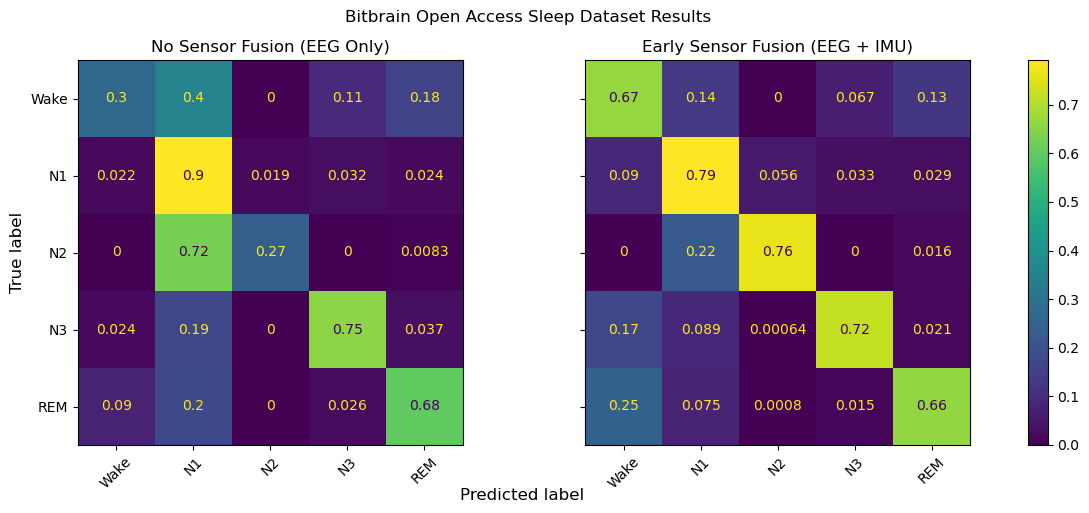

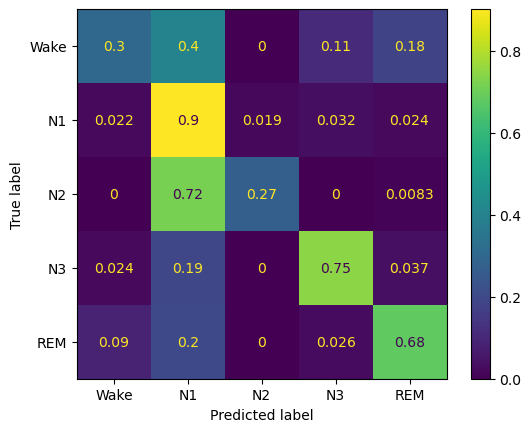

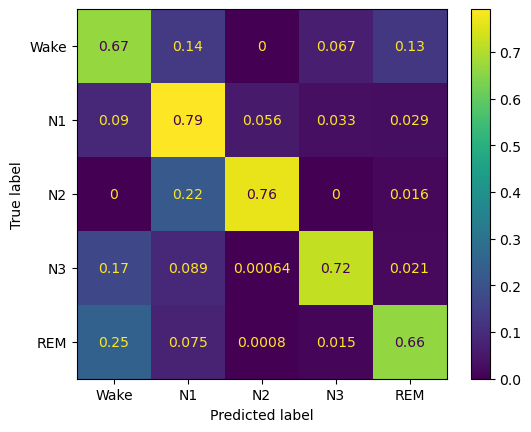

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5), sharey='row')
fig.suptitle('Bitbrain Open Access Sleep Dataset Results', x=0.45)
cmap = 'viridis'

cm = ConfusionMatrixDisplay.from_predictions(all_y_true, all_stage_pred, display_labels=STAGE_LABELS, normalize="true")
cm.plot(ax=ax1, xticks_rotation=45, cmap=cmap)
cm.ax_.set_title('No Sensor Fusion (EEG Only)')
cm.im_.colorbar.remove()
cm.ax_.set_xlabel('')
cm.ax_.set_ylabel('True label', size = 'large')

cm_fusion = ConfusionMatrixDisplay.from_predictions(all_y_true, all_fusion_pred, display_labels=STAGE_LABELS, normalize="true")
cm_fusion.plot(ax=ax2, xticks_rotation=45, cmap=cmap)
cm_fusion.ax_.set_title('Early Sensor Fusion (EEG + IMU)')
cm_fusion.im_.colorbar.remove()
cm_fusion.ax_.set_xlabel('')
cm_fusion.ax_.set_ylabel('')

fig.text(0.405, 0, 'Predicted label', ha='left', size = 'large')
plt.subplots_adjust(wspace=0.40, hspace=0.1)
fig.colorbar(cm_fusion.im_, ax=(ax1, ax2))
plt.show()